In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Conv3D, Flatten, Dense, Reshape, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.utils import np_utils
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score
from operator import truediv
from scipy.io import loadmat
from scipy.signal import savgol_filter
from plotly.offline import init_notebook_mode
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import spectral
import gc

init_notebook_mode(connected=True)


In [2]:
X_raw=loadmat('../input/salinas/salinas_corrected.mat')['salinas_corrected']
y_raw=loadmat('../input/salinas/salinas_gt.mat')['salinas_gt']


In [3]:
test_ratio=0.8
pixelsize=25


In [4]:
def padWithZeros(X, margin=2):
    newX = np.zeros((X.shape[0] + 2 * margin, X.shape[1] + 2* margin, X.shape[2]))
    x_offset = margin
    y_offset = margin
    newX[x_offset:X.shape[0] + x_offset, y_offset:X.shape[1] + y_offset, :] = X
    return newX

def applyPCA(X, numComponents=75):
    newX = np.reshape(X, (-1, X.shape[2]))
    pca = PCA(n_components=numComponents, whiten=True)
    newX = pca.fit_transform(newX)
    newX = np.reshape(newX, (X.shape[0],X.shape[1], numComponents))
    return newX, pca

def createImageCubes(X, y, windowSize=5, removeZeroLabels = True):
    margin = int((windowSize - 1) / 2)
    zeroPaddedX = padWithZeros(X, margin=margin)
    # split patches
    patchesData = np.zeros((X.shape[0] * X.shape[1], windowSize, windowSize, X.shape[2]))
    patchesLabels = np.zeros((X.shape[0] * X.shape[1]))
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0] - margin):
        for c in range(margin, zeroPaddedX.shape[1] - margin):
            patch = zeroPaddedX[r - margin:r + margin + 1, c - margin:c + margin + 1]   
            patchesData[patchIndex, :, :, :] = patch
            patchesLabels[patchIndex] = y[r-margin, c-margin]
            patchIndex = patchIndex + 1
    if removeZeroLabels:
        patchesData = patchesData[patchesLabels>0,:,:,:]
        patchesLabels = patchesLabels[patchesLabels>0]
        patchesLabels -= 1
    return patchesData, patchesLabels

def splitTrainTestSet(X, y, testRatio, randomState=345):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=testRatio, random_state=randomState,
                                                        stratify=y)
    return X_train, X_test, y_train, y_test

# Preprocessing helper functions
def snv(X):
    mean_vec = np.mean(X, axis=1, keepdims=True)
    std_vec = np.std(X, axis=1, keepdims=True)
    std_vec[std_vec == 0] = 1.0
    return (X - mean_vec) / std_vec

def msc(X):
    ref = np.mean(X, axis=0)
    out = np.zeros_like(X)
    for i in range(X.shape[0]):
        sl, ic = np.polyfit(ref, X[i], 1)
        if sl == 0:
            sl = 1.0
        out[i] = (X[i] - ic) / sl
    return out

def sg(X, deriv=0):
    return np.array([savgol_filter(r, 31, 2, deriv=deriv) for r in X])

def preprocess_pipeline(X_cube, pipeline_name):
    if pipeline_name == 'RAW':
        return X_cube.copy()
    
    print(f"Applying preprocessing: {pipeline_name}")
    shape_orig = X_cube.shape
    X_2d = X_cube.reshape(-1, shape_orig[2]).astype(np.float64)
    
    if 'SG1' in pipeline_name:
        X_2d = sg(X_2d, deriv=1)
        print("  Applied SG1 (1st derivative)")
    elif 'SG' in pipeline_name:
        X_2d = sg(X_2d, deriv=0)
        print("  Applied SG (smoothing)")
        
    if 'MSC' in pipeline_name:
        X_2d = msc(X_2d)
        print("  Applied MSC")
    elif 'SVN' in pipeline_name or 'SNV' in pipeline_name:
        X_2d = snv(X_2d)
        print("  Applied SVN/SNV")
        
    return X_2d.reshape(shape_orig).astype(np.float32)

def build_model(pixelsize, num_components, num_classes):
    input_layer = Input((pixelsize, pixelsize, num_components, 1))
    conv_layer1 = Conv3D(filters=8, kernel_size=(3, 3, 7), activation='relu')(input_layer)
    conv_layer2 = Conv3D(filters=16, kernel_size=(3, 3, 5), activation='relu')(conv_layer1)
    conv_layer3 = Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu')(conv_layer2)
    conv3d_shape = conv_layer3.shape
    conv_layer3 = Reshape((conv3d_shape[1], conv3d_shape[2], conv3d_shape[3]*conv3d_shape[4]))(conv_layer3)
    conv_layer4 = Conv2D(filters=64, kernel_size=(3,3), activation='relu')(conv_layer3)
    flatten_layer = Flatten()(conv_layer4)
    dense_layer1 = Dense(units=256, activation='relu')(flatten_layer)
    dense_layer1 = Dropout(0.4)(dense_layer1)
    dense_layer2 = Dense(units=128, activation='relu')(dense_layer1)
    dense_layer2 = Dropout(0.4)(dense_layer2)
    output_layer = Dense(units=num_classes, activation='softmax')(dense_layer2)
    model = Model(inputs=input_layer, outputs=output_layer)
    return model

def AA_andEachClassAccuracy(confusion_matrix):
    counter= confusion_matrix[0]
    list_diag= np.diag(confusion_matrix)
    list_raw_sum= np.sum(confusion_matrix,axis=1)
    each_acc=np.nan_to_num(truediv(list_diag,list_raw_sum))
    average_acc=np.mean(each_acc)
    return each_acc, average_acc

def reports(model, X_test, y_test, name):
    import time
    start = time.time()
    Y_pred = model.predict(X_test)
    y_pred = np.argmax(Y_pred, axis=1)
    end = time.time()
    print("Prediction time:", end - start)
    target_names = ['Brocoli_green_weeds_1','Brocoli_green_weeds_2','Fallow','Fallow_rough_plow','Fallow_smooth',
                    'Stubble','Celery','Grapes_untrained','Soil_vinyard_develop','Corn_senesced_green_weeds',
                    'Lettuce_romaine_4wk','Lettuce_romaine_5wk','Lettuce_romaine_6wk','Lettuce_romaine_7wk',
                    'Vinyard_untrained','Vinyard_vertical_trellis']
    classification = classification_report(np.argmax(y_test, axis=1), y_pred, target_names=target_names)
    oa = accuracy_score(np.argmax(y_test, axis=1), y_pred)
    confusion = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
    each_acc, aa = AA_andEachClassAccuracy(confusion)
    kappa = cohen_kappa_score(np.argmax(y_test, axis=1), y_pred)
    score = model.evaluate(X_test, y_test, batch_size=32)
    Test_Loss = score[0] * 100
    Test_accuracy = score[1] * 100
    return classification, confusion, Test_Loss, Test_accuracy, oa * 100, each_acc * 100, aa * 100, kappa * 100


In [5]:
X_raw.shape, y_raw.shape


((512, 217, 204), (512, 217))

In [ ]:
pipelines = ['RAW', '10_SG_MSC', '10_SG_SVN', '10_SG1_MSC', '10_SG1_SVN']

for pipeline in pipelines:
    print(f"\n{'='*60}")
    print(f"Running pipeline: {pipeline}")
    print(f"{'='*60}")
    
    # 1. Preprocess
    X_proc = preprocess_pipeline(X_raw, pipeline)
    
    # 2. PCA
    X_pca, pca = applyPCA(X_proc, numComponents=15)
    
    # 3. Create Cubes
    X_cubes, y_cubes = createImageCubes(X_pca, y_raw, windowSize=pixelsize)
    
    # 4. Split Train/Test
    Xtrain, Xtest, ytrain, ytest = splitTrainTestSet(X_cubes, y_cubes, test_ratio)
    
    # 5. Split Train/Valid
    Xtrain, Xvalid, ytrain, yvalid = splitTrainTestSet(Xtrain, ytrain, 0.3333)
    
    # 6. Reshape & OHE
    Xtrain = Xtrain.reshape(-1, pixelsize, pixelsize, 15, 1)
    Xvalid = Xvalid.reshape(-1, pixelsize, pixelsize, 15, 1)
    Xtest = Xtest.reshape(-1, pixelsize, pixelsize, 15, 1)
    
    ytrain = np_utils.to_categorical(ytrain)
    yvalid = np_utils.to_categorical(yvalid)
    ytest_cat = np_utils.to_categorical(ytest)
    
    # 7. Build and Compile Model
    model = build_model(pixelsize, 15, 16)
    adam = Adam(learning_rate=0.001, decay=1e-06)
    model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Checkpoint
    filepath = f"best-model-{pipeline}.hdf5"
    checkpoint = ModelCheckpoint(filepath=filepath, monitor='accuracy', verbose=1, save_best_only=True, mode='max')
    
    # 8. Fit
    history = model.fit(x=Xtrain, y=ytrain, validation_data=(Xvalid, yvalid), batch_size=256, epochs=20, callbacks=[checkpoint])
    
    # Save the last model just in case
    model.save(f"best-model1-{pipeline}.hdf5")
    
    # 9. Load best weights and evaluate
    model.load_weights(filepath)
    model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
    
    # 10. Generate Reports
    classification, confusion, Test_loss, Test_accuracy, oa, each_acc, aa, kappa = reports(model, Xtest, ytest_cat, 'SU')
    
    print(f"Test Accuracy ({pipeline}): {Test_accuracy:.2f}%")
    
    # Save Report to file
    report_name = f"classification_report_{pipeline}.txt"
    with open(report_name, 'w') as x_file:
        x_file.write('{} Test loss (%)\n'.format(Test_loss))
        x_file.write('{} Test accuracy (%)\n\n'.format(Test_accuracy))
        x_file.write('{} Kappa accuracy (%)\n'.format(kappa))
        x_file.write('{} Overall accuracy (%)\n'.format(oa))
        x_file.write('{} Average accuracy (%)\n\n'.format(aa))
        x_file.write('{}\n\n'.format(classification))
        x_file.write('{}'.format(confusion))
        
    # Plotting Loss
    plt.figure(figsize=(7,7)) 
    plt.grid() 
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.ylabel('Loss') 
    plt.xlabel('Epochs')
    plt.legend(['Training','Validation'], loc='upper right') 
    plt.savefig(f"loss_curve_{pipeline}.pdf") 
    plt.close()
    
    # Plotting Accuracy
    plt.figure(figsize=(5,5)) 
    plt.ylim(0,1.1) 
    plt.grid() 
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.ylabel('Accuracy') 
    plt.xlabel('Epochs') 
    plt.legend(['Training','Validation']) 
    plt.savefig(f"acc_curve_{pipeline}.pdf") 
    plt.close()
    
    print(f"Finished pipeline: {pipeline}. Results and plots saved.")
    
    # 11. Cleanup memory
    del model, Xtrain, Xvalid, Xtest, ytrain, yvalid, ytest_cat, X_proc, X_pca, X_cubes
    tf.keras.backend.clear_session()
    gc.collect()


In [ ]:
# Reload the RAW model and load the RAW weights so the classification map is based on RAW
model = build_model(pixelsize, 15, 16)
model.load_weights("best-model-RAW.hdf5")


In [28]:
def Patch(data,height_index,width_index):
    height_slice=slice(height_index,height_index+PATCH_SIZE)
    width_slice = slice(width_index, width_index+PATCH_SIZE)
    patch = data[height_slice, width_slice, :]
    
    return patch

In [29]:
X=loadmat('../input/salinas/salinas_corrected.mat')['salinas_corrected']
y=loadmat('../input/salinas/salinas_gt.mat')['salinas_gt']

In [30]:
height=y.shape[0]
weidth=y.shape[1]
PATCH_SIZE=25
numComponents=15

In [31]:
X,pca=applyPCA(X,numComponents=numComponents)


In [32]:
X=padWithZeros(X,PATCH_SIZE//2)


In [33]:
outputs=np.zeros((height,weidth))
for i in range (height):
    for j in range (weidth):
        target=int(y[i,j])
        if target==0:
            continue
        else:
            image_patch=Patch(X,i,j)
            X_test_image = image_patch.reshape(1,image_patch.shape[0],image_patch.shape[1], image_patch.shape[2], 1).astype('float32')                                   
            prediction=(model.predict(X_test_image))
            prediction=np.argmax(prediction,axis=1)
            outputs[i][j]=prediction+1

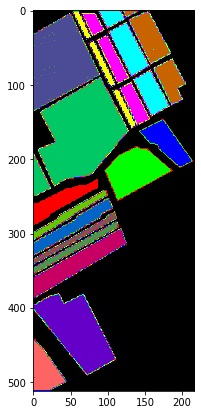

In [34]:
ground_truth = spectral.imshow(classes = y,figsize =(7,7))


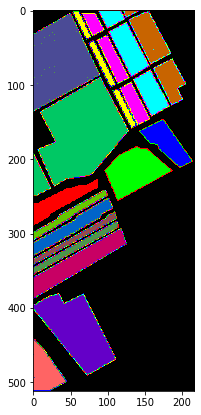

In [35]:
predict_image = spectral.imshow(classes = outputs.astype(int),figsize =(7,7))


In [36]:
spectral.save_rgb("prediction2.jpg", outputs.astype(int), colors=spectral.spy_colors)